# 260319 KuaiRec Results Figures (Clean Version)

This notebook creates concise, presentation-ready figures from aggregated CSV files.

Design rules applied:
- Figure text is English only (to avoid font/glyph issues).
- Korean interpretation is printed below each figure.
- No crowded x-axis: at most 6 categories per chart.
- Zoomed y-axis is used to show subtle differences clearly.

In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
SAVE_FIG = False

# Resolve repository root robustly even when notebook cwd is docs/.
cwd = Path.cwd().resolve()
ROOT = None
for p in [cwd] + list(cwd.parents):
    if (p / "experiments").exists() and (p / "Makefile").exists():
        ROOT = p
        break
if ROOT is None:
    raise RuntimeError("Could not locate repository root containing experiments/ and Makefile")

DATA_DIR = ROOT / "experiments/run/fmoe_n3/docs/data"
DOC_DIR = ROOT / "experiments/run/fmoe_n3/docs"
FIG_DIR = ROOT / "experiments/run/fmoe_n3/docs/figures"
LOG_DIR = ROOT / "experiments/run/artifacts/logs/fmoe_n3"
FIG_DIR.mkdir(parents=True, exist_ok=True)

baseline_best = pd.read_csv(DATA_DIR / "260319_baseline_kuairec_model_best.csv")
baseline_winners = pd.read_csv(DATA_DIR / "260319_baseline_kuairec_metric_winners.csv")
fmoe_all = pd.read_csv(DATA_DIR / "260319_fmoe_n3_kuairec_all.csv")
axis_agg = pd.read_csv(DATA_DIR / "260319_phase4_axis_agg.csv")
axis_rows = pd.read_csv(DATA_DIR / "260319_phase4_axis_rows.csv")

# trial-level phase summaries (richer than sidecar means)
phase4_trial = pd.read_csv(LOG_DIR / "phase4_residual_topk_v2/phase4_residual_topk_v2_summary.csv")
phase4_trial = phase4_trial[phase4_trial["log_rel_path"].astype(str).str.contains("KuaiRecLargeStrictPosV2_0.2", na=False)].copy()

# Remove duplicated mirrors using run_id.
fmoe_unique = (
    fmoe_all.sort_values(["best_valid_mrr20", "best_valid_test_mrr20"], ascending=False)
    .drop_duplicates(subset=["run_id"], keep="first")
)

def zoom_ylim(values, pad_ratio=0.15, min_pad=0.00015):
    vmin = float(np.min(values))
    vmax = float(np.max(values))
    span = vmax - vmin
    pad = max(span * pad_ratio, min_pad)
    return vmin - pad, vmax + pad

def maybe_savefig(path, **kwargs):
    if SAVE_FIG:
        plt.savefig(path, **kwargs)

print("데이터 로드 완료")
print(f"- baseline models: {len(baseline_best)}")
print(f"- fmoe unique runs: {len(fmoe_unique)}")
print(f"- axis variations(sidecar): {len(axis_agg)}")
print(f"- phase4 trial rows: {len(phase4_trial)}")
print("- png 저장: 비활성화(SAVE_FIG=False)")

데이터 로드 완료
- baseline models: 8
- fmoe unique runs: 371
- axis variations(sidecar): 21
- phase4 trial rows: 299
- png 저장: 비활성화(SAVE_FIG=False)


In [2]:
# Phase/Axes narrative map from result markdown files
summary_md = (DOC_DIR / "260317_summary.md").read_text(encoding="utf-8")
phase4_md = (DOC_DIR / "phase4_results.md").read_text(encoding="utf-8")
phase5_md = (DOC_DIR / "phase5_results.md").read_text(encoding="utf-8")

phase_axis_map = {
    "Core": ["dense vs moe", "router source(hidden/feature/both)", "feature injection on/off", "top-k/len/encoder"],
    "P1": ["A/F/L/N/S/X anchors", "layout/length/scheduler expansion"],
    "P2": ["router block", "feature block", "aux-reg block"],
    "P3": ["S1 standard(flat)", "S2 factored(group)", "S3 feature-source", "S4 deep-prefix"],
    "P4": ["R residual modes", "K experts/top-k", "F feature path variants"],
    "P5": ["specialization regularization", "method M0~M4 + combo C0~C7"],
    "P6": ["final candidate screening"],
}

print("\n[문서 기반 실험 축 맵]")
for ph, axes in phase_axis_map.items():
    print(f"- {ph}: {', '.join(axes)}")

print("\n[이번 노트북 구성]")
print("1) P3 구조 옵션 비교: flat vs factored(group) 등")
print("2) P4 R축 옵션 비교: residual mode 변화")
print("3) P4 K축 옵션 비교: expert/top-k family 변화")
print("4) P4 F축 옵션 비교: hidden/feature/both(injection) 경로")
print("5) 모든 그래프는 valid/test 분리 + max/mean/std 표시")


[문서 기반 실험 축 맵]
- Core: dense vs moe, router source(hidden/feature/both), feature injection on/off, top-k/len/encoder
- P1: A/F/L/N/S/X anchors, layout/length/scheduler expansion
- P2: router block, feature block, aux-reg block
- P3: S1 standard(flat), S2 factored(group), S3 feature-source, S4 deep-prefix
- P4: R residual modes, K experts/top-k, F feature path variants
- P5: specialization regularization, method M0~M4 + combo C0~C7
- P6: final candidate screening

[이번 노트북 구성]
1) P3 구조 옵션 비교: flat vs factored(group) 등
2) P4 R축 옵션 비교: residual mode 변화
3) P4 K축 옵션 비교: expert/top-k family 변화
4) P4 F축 옵션 비교: hidden/feature/both(injection) 경로
5) 모든 그래프는 valid/test 분리 + max/mean/std 표시


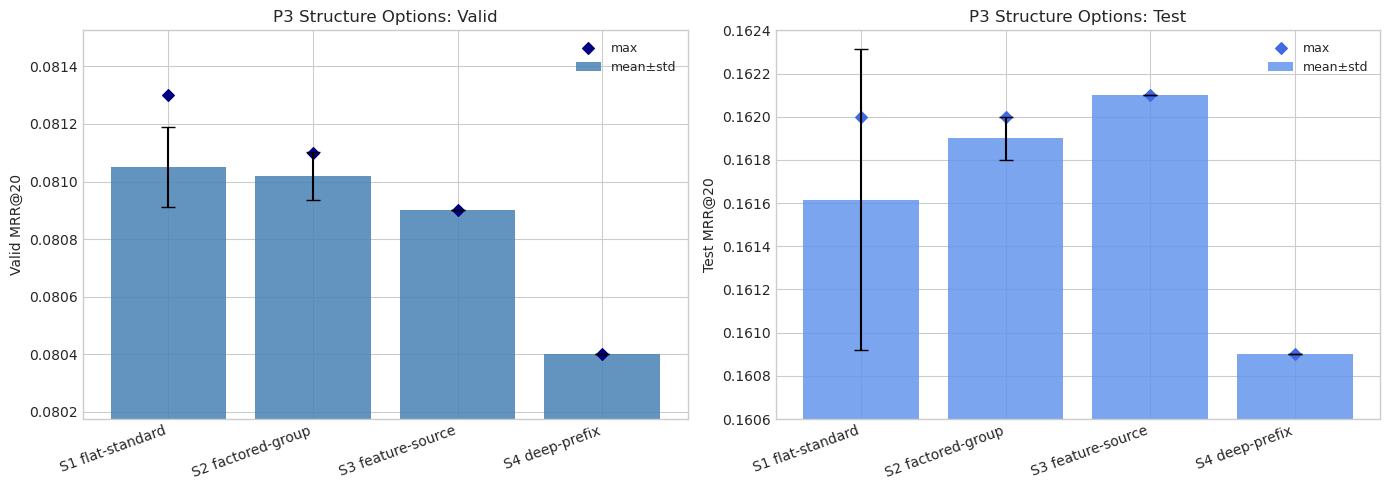


[해석] P3 구조 옵션 비교 (flat vs factored/group)
           option  n  valid_mean  valid_std  valid_max  test_mean  test_std  test_max
 S1 flat-standard  6     0.08105   0.000138     0.0813   0.161617  0.000697    0.1620
S2 factored-group  5     0.08102   0.000084     0.0811   0.161900  0.000100    0.1620
S3 feature-source  1     0.08090   0.000000     0.0809   0.162100  0.000000    0.1621
   S4 deep-prefix  1     0.08040   0.000000     0.0804   0.160900  0.000000    0.1609
- 이 표는 옵션별 max/mean/std를 동시에 보여주며, 단일 best만 보는 편향을 줄인다.


In [3]:
# Figure 1: P3 structure options (flat vs factored/group etc.)
p3 = fmoe_unique[fmoe_unique["run_id"].str.contains(r"^p3s[1-4]_", regex=True)].copy()

def p3_option(run_id: str) -> str:
    rid = str(run_id).lower()
    if "p3s1_" in rid:
        return "S1 flat-standard"
    if "p3s2_" in rid:
        return "S2 factored-group"
    if "p3s3_" in rid:
        return "S3 feature-source"
    if "p3s4_" in rid:
        return "S4 deep-prefix"
    return "other"

p3["option"] = p3["run_id"].map(p3_option)
p3_stats = p3.groupby("option", as_index=False).agg(
    n=("run_id", "count"),
    valid_mean=("best_valid_mrr20", "mean"),
    valid_std=("best_valid_mrr20", "std"),
    valid_max=("best_valid_mrr20", "max"),
    test_mean=("best_valid_test_mrr20", "mean"),
    test_std=("best_valid_test_mrr20", "std"),
    test_max=("best_valid_test_mrr20", "max"),
)
p3_stats = p3_stats[p3_stats["option"] != "other"].sort_values("valid_mean", ascending=False)
p3_stats[["valid_std", "test_std"]] = p3_stats[["valid_std", "test_std"]].fillna(0.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(p3_stats))

bars1 = ax1.bar(x, p3_stats["valid_mean"], yerr=p3_stats["valid_std"], capsize=5, color="steelblue", alpha=0.85, label="mean±std")
ax1.scatter(x, p3_stats["valid_max"], color="navy", marker="D", s=35, label="max")
ax1.set_title("P3 Structure Options: Valid")
ax1.set_xticks(x)
ax1.set_xticklabels(p3_stats["option"], rotation=20, ha="right")
ax1.set_ylabel("Valid MRR@20")
ax1.set_ylim(*zoom_ylim(np.r_[p3_stats["valid_mean"], p3_stats["valid_max"]], pad_ratio=0.25))
ax1.legend(fontsize=9)

bars2 = ax2.bar(x, p3_stats["test_mean"], yerr=p3_stats["test_std"], capsize=5, color="cornflowerblue", alpha=0.85, label="mean±std")
ax2.scatter(x, p3_stats["test_max"], color="royalblue", marker="D", s=35, label="max")
ax2.set_title("P3 Structure Options: Test")
ax2.set_xticks(x)
ax2.set_xticklabels(p3_stats["option"], rotation=20, ha="right")
ax2.set_ylabel("Test MRR@20")
ax2.set_ylim(*zoom_ylim(np.r_[p3_stats["test_mean"], p3_stats["test_max"]], pad_ratio=0.25))
ax2.legend(fontsize=9)

plt.tight_layout()
maybe_savefig(FIG_DIR / "260319_clean_p3_structure_stats.png", dpi=220, bbox_inches="tight")
plt.show()

print("\n[해석] P3 구조 옵션 비교 (flat vs factored/group)")
print(p3_stats[["option", "n", "valid_mean", "valid_std", "valid_max", "test_mean", "test_std", "test_max"]].to_string(index=False))
print("- 이 표는 옵션별 max/mean/std를 동시에 보여주며, 단일 best만 보는 편향을 줄인다.")

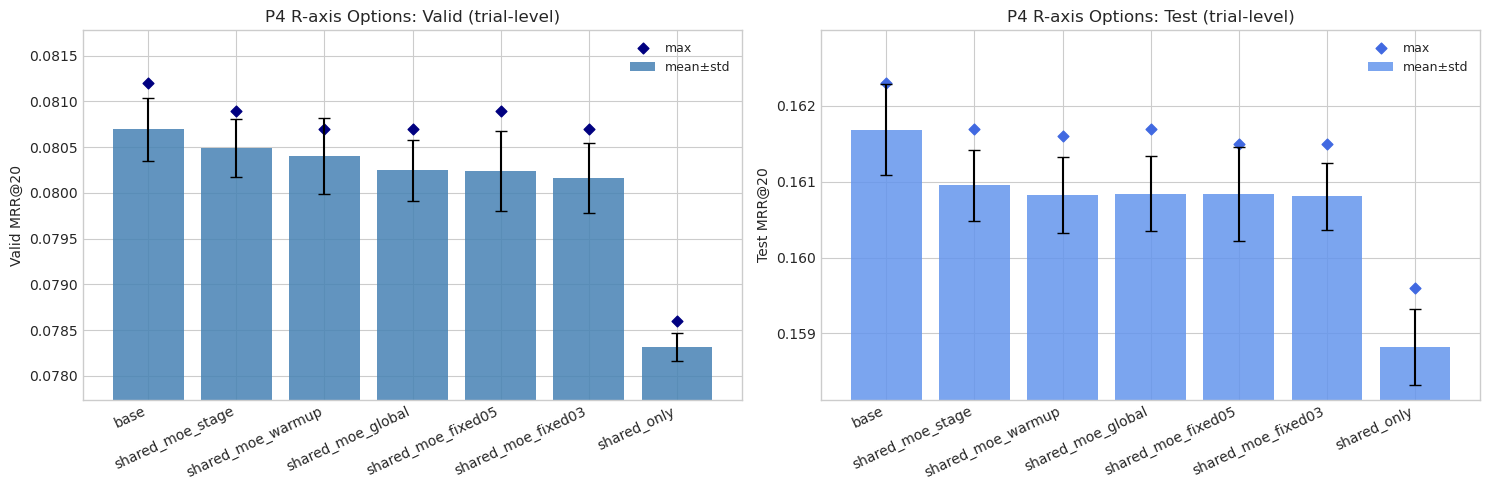


[해석] P4 R축(Residual mode) 옵션 비교 - trial level
    variation_slug  n  valid_mean  valid_std  valid_max  test_mean  test_std  test_max
              base 16    0.080694   0.000347     0.0812   0.161688  0.000600    0.1623
  shared_moe_stage 16    0.080488   0.000316     0.0809   0.160950  0.000469    0.1617
 shared_moe_warmup 16    0.080400   0.000413     0.0807   0.160825  0.000505    0.1616
 shared_moe_global 20    0.080245   0.000328     0.0807   0.160840  0.000495    0.1617
shared_moe_fixed05 18    0.080239   0.000437     0.0809   0.160839  0.000624    0.1615
shared_moe_fixed03 17    0.080165   0.000386     0.0807   0.160806  0.000444    0.1615
       shared_only 17    0.078318   0.000155     0.0786   0.158824  0.000498    0.1596


In [4]:
# Figure 2: P4 R-axis options (residual modes, trial-level)
r_df = phase4_trial[phase4_trial["run_phase"].astype(str).str.startswith("R_")].copy()
r_df["variation_slug"] = r_df["run_phase"].str.extract(r"^R_([^_]+(?:_[^_]+)*)_C\d$")[0]

r_stats = r_df.groupby("variation_slug", as_index=False).agg(
    n=("best_mrr20_trial", "count"),
    valid_mean=("best_mrr20_trial", "mean"),
    valid_std=("best_mrr20_trial", "std"),
    valid_max=("best_mrr20_trial", "max"),
    test_mean=("test_mrr20_trial", "mean"),
    test_std=("test_mrr20_trial", "std"),
    test_max=("test_mrr20_trial", "max"),
).sort_values("valid_mean", ascending=False)
r_stats[["valid_std", "test_std"]] = r_stats[["valid_std", "test_std"]].fillna(0.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(r_stats))

ax1.bar(x, r_stats["valid_mean"], yerr=r_stats["valid_std"], capsize=4, color="steelblue", alpha=0.85, label="mean±std")
ax1.scatter(x, r_stats["valid_max"], color="navy", marker="D", s=30, label="max")
ax1.set_title("P4 R-axis Options: Valid (trial-level)")
ax1.set_xticks(x)
ax1.set_xticklabels(r_stats["variation_slug"], rotation=25, ha="right")
ax1.set_ylabel("Valid MRR@20")
ax1.set_ylim(*zoom_ylim(np.r_[r_stats["valid_mean"], r_stats["valid_max"]], pad_ratio=0.2))
ax1.legend(fontsize=9)

ax2.bar(x, r_stats["test_mean"], yerr=r_stats["test_std"], capsize=4, color="cornflowerblue", alpha=0.85, label="mean±std")
ax2.scatter(x, r_stats["test_max"], color="royalblue", marker="D", s=30, label="max")
ax2.set_title("P4 R-axis Options: Test (trial-level)")
ax2.set_xticks(x)
ax2.set_xticklabels(r_stats["variation_slug"], rotation=25, ha="right")
ax2.set_ylabel("Test MRR@20")
ax2.set_ylim(*zoom_ylim(np.r_[r_stats["test_mean"], r_stats["test_max"]], pad_ratio=0.2))
ax2.legend(fontsize=9)

plt.tight_layout()
maybe_savefig(FIG_DIR / "260319_clean_p4_r_stats.png", dpi=220, bbox_inches="tight")
plt.show()

print("\n[해석] P4 R축(Residual mode) 옵션 비교 - trial level")
print(r_stats[["variation_slug", "n", "valid_mean", "valid_std", "valid_max", "test_mean", "test_std", "test_max"]].to_string(index=False))

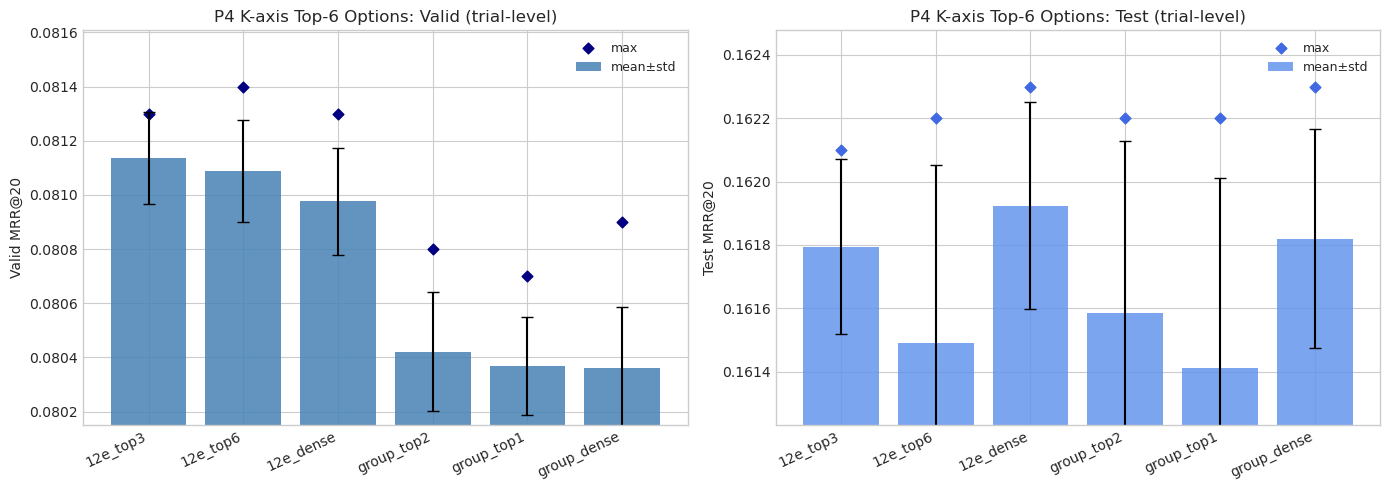


[해석] P4 K축(top-k/expert) 옵션 비교 - Top6 trial level
variation_slug  n  valid_mean  valid_std  valid_max  test_mean  test_std  test_max
      12e_top3 19    0.081137   0.000171     0.0813   0.161795  0.000276    0.1621
      12e_top6 18    0.081089   0.000188     0.0814   0.161489  0.000563    0.1622
     12e_dense 17    0.080976   0.000199     0.0813   0.161924  0.000327    0.1623
    group_top2 14    0.080421   0.000219     0.0808   0.161586  0.000542    0.1622
    group_top1 19    0.080368   0.000183     0.0807   0.161411  0.000602    0.1622
   group_dense 15    0.080360   0.000226     0.0809   0.161820  0.000347    0.1623


In [5]:
# Figure 3: P4 K-axis options (top-k / expert grouping, trial-level)
k_df = phase4_trial[phase4_trial["run_phase"].astype(str).str.startswith("K_")].copy()
k_df["variation_slug"] = k_df["run_phase"].str.extract(r"^K_([^_]+(?:_[^_]+)*)_C\d$")[0]

k_stats = k_df.groupby("variation_slug", as_index=False).agg(
    n=("best_mrr20_trial", "count"),
    valid_mean=("best_mrr20_trial", "mean"),
    valid_std=("best_mrr20_trial", "std"),
    valid_max=("best_mrr20_trial", "max"),
    test_mean=("test_mrr20_trial", "mean"),
    test_std=("test_mrr20_trial", "std"),
    test_max=("test_mrr20_trial", "max"),
).sort_values("valid_mean", ascending=False)
k_stats[["valid_std", "test_std"]] = k_stats[["valid_std", "test_std"]].fillna(0.0)

# avoid crowded x-axis: top 6 by valid mean
k_top = k_stats.head(6).copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(k_top))

ax1.bar(x, k_top["valid_mean"], yerr=k_top["valid_std"], capsize=4, color="steelblue", alpha=0.85, label="mean±std")
ax1.scatter(x, k_top["valid_max"], color="navy", marker="D", s=30, label="max")
ax1.set_title("P4 K-axis Top-6 Options: Valid (trial-level)")
ax1.set_xticks(x)
ax1.set_xticklabels(k_top["variation_slug"], rotation=25, ha="right")
ax1.set_ylabel("Valid MRR@20")
ax1.set_ylim(*zoom_ylim(np.r_[k_top["valid_mean"], k_top["valid_max"]], pad_ratio=0.2))
ax1.legend(fontsize=9)

ax2.bar(x, k_top["test_mean"], yerr=k_top["test_std"], capsize=4, color="cornflowerblue", alpha=0.85, label="mean±std")
ax2.scatter(x, k_top["test_max"], color="royalblue", marker="D", s=30, label="max")
ax2.set_title("P4 K-axis Top-6 Options: Test (trial-level)")
ax2.set_xticks(x)
ax2.set_xticklabels(k_top["variation_slug"], rotation=25, ha="right")
ax2.set_ylabel("Test MRR@20")
ax2.set_ylim(*zoom_ylim(np.r_[k_top["test_mean"], k_top["test_max"]], pad_ratio=0.2))
ax2.legend(fontsize=9)

plt.tight_layout()
maybe_savefig(FIG_DIR / "260319_clean_p4_k_stats_top6.png", dpi=220, bbox_inches="tight")
plt.show()

print("\n[해석] P4 K축(top-k/expert) 옵션 비교 - Top6 trial level")
print(k_top[["variation_slug", "n", "valid_mean", "valid_std", "valid_max", "test_mean", "test_std", "test_max"]].to_string(index=False))

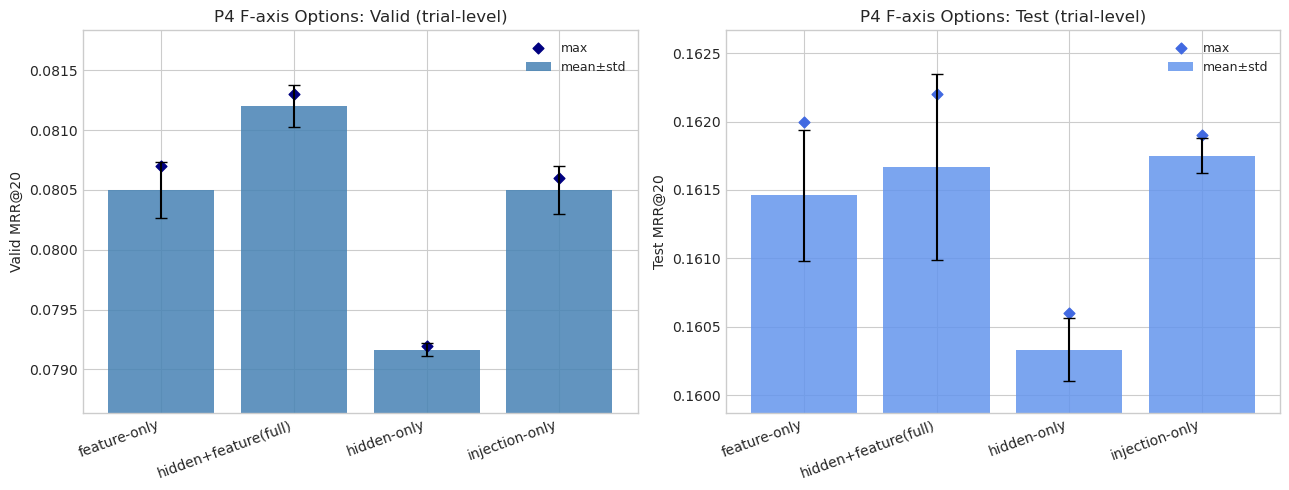


[해석] P4 F축(hidden/feature/both 계열) 옵션 비교 - trial level
              option  n  valid_mean  valid_std  valid_max  test_mean  test_std  test_max
        feature-only  5    0.080500   0.000235     0.0807   0.161460  0.000477    0.1620
hidden+feature(full)  3    0.081200   0.000173     0.0813   0.161667  0.000681    0.1622
         hidden-only  3    0.079167   0.000058     0.0792   0.160333  0.000231    0.1606
      injection-only  4    0.080500   0.000200     0.0806   0.161750  0.000129    0.1619


In [6]:
# Figure 4: P4 F-axis options (hidden / feature / full / injection, trial-level)
f_df = phase4_trial[phase4_trial["run_phase"].astype(str).str.startswith("F_")].copy()
f_df["variation_slug"] = f_df["run_phase"].str.extract(r"^F_([^_]+(?:_[^_]+)*)_C\d$")[0]

f_stats = f_df.groupby("variation_slug", as_index=False).agg(
    n=("best_mrr20_trial", "count"),
    valid_mean=("best_mrr20_trial", "mean"),
    valid_std=("best_mrr20_trial", "std"),
    valid_max=("best_mrr20_trial", "max"),
    test_mean=("test_mrr20_trial", "mean"),
    test_std=("test_mrr20_trial", "std"),
    test_max=("test_mrr20_trial", "max"),
).sort_values("variation_slug")
f_stats[["valid_std", "test_std"]] = f_stats[["valid_std", "test_std"]].fillna(0.0)

name_map = {
    "feat_hidden_only": "hidden-only",
    "feat_feature_only": "feature-only",
    "feat_full": "hidden+feature(full)",
    "feat_injection_only": "injection-only",
}
f_stats["option"] = f_stats["variation_slug"].map(lambda x: name_map.get(x, x))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(f_stats))

ax1.bar(x, f_stats["valid_mean"], yerr=f_stats["valid_std"], capsize=4, color="steelblue", alpha=0.85, label="mean±std")
ax1.scatter(x, f_stats["valid_max"], color="navy", marker="D", s=30, label="max")
ax1.set_title("P4 F-axis Options: Valid (trial-level)")
ax1.set_xticks(x)
ax1.set_xticklabels(f_stats["option"], rotation=20, ha="right")
ax1.set_ylabel("Valid MRR@20")
ax1.set_ylim(*zoom_ylim(np.r_[f_stats["valid_mean"], f_stats["valid_max"]], pad_ratio=0.25))
ax1.legend(fontsize=9)

ax2.bar(x, f_stats["test_mean"], yerr=f_stats["test_std"], capsize=4, color="cornflowerblue", alpha=0.85, label="mean±std")
ax2.scatter(x, f_stats["test_max"], color="royalblue", marker="D", s=30, label="max")
ax2.set_title("P4 F-axis Options: Test (trial-level)")
ax2.set_xticks(x)
ax2.set_xticklabels(f_stats["option"], rotation=20, ha="right")
ax2.set_ylabel("Test MRR@20")
ax2.set_ylim(*zoom_ylim(np.r_[f_stats["test_mean"], f_stats["test_max"]], pad_ratio=0.25))
ax2.legend(fontsize=9)

plt.tight_layout()
maybe_savefig(FIG_DIR / "260319_clean_p4_f_stats.png", dpi=220, bbox_inches="tight")
plt.show()

print("\n[해석] P4 F축(hidden/feature/both 계열) 옵션 비교 - trial level")
print(f_stats[["option", "n", "valid_mean", "valid_std", "valid_max", "test_mean", "test_std", "test_max"]].to_string(index=False))

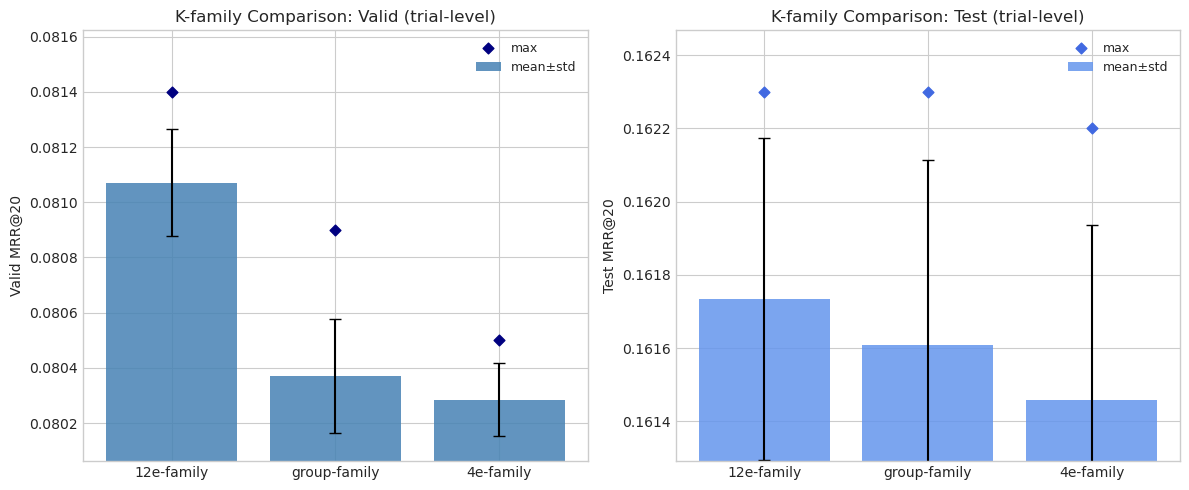


[해석] K-family 통계 (group vs non-group) - trial level
      family  n  valid_mean  valid_std  valid_max  test_mean  test_std  test_max
  12e-family 54    0.081070   0.000194     0.0814   0.161733  0.000440    0.1623
group-family 63    0.080371   0.000207     0.0809   0.161608  0.000507    0.1623
   4e-family 47    0.080285   0.000133     0.0805   0.161460  0.000476    0.1622
- group 계열과 12e/4e 계열을 family 수준으로 정리해 옵션 선택 근거를 제시


In [7]:
# Figure 5: K-axis family-level stats (group vs non-group, trial-level)
k_family = k_df.copy()

def family_of(v):
    s = str(v)
    if s.startswith("group"):
        return "group-family"
    if s.startswith("12e_"):
        return "12e-family"
    if s.startswith("4e_"):
        return "4e-family"
    return "other"

k_family["family"] = k_family["variation_slug"].map(family_of)
kf = k_family.groupby("family", as_index=False).agg(
    n=("best_mrr20_trial", "count"),
    valid_mean=("best_mrr20_trial", "mean"),
    valid_std=("best_mrr20_trial", "std"),
    valid_max=("best_mrr20_trial", "max"),
    test_mean=("test_mrr20_trial", "mean"),
    test_std=("test_mrr20_trial", "std"),
    test_max=("test_mrr20_trial", "max"),
).sort_values("valid_mean", ascending=False)
kf[["valid_std", "test_std"]] = kf[["valid_std", "test_std"]].fillna(0.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(kf))

ax1.bar(x, kf["valid_mean"], yerr=kf["valid_std"], capsize=4, color="steelblue", alpha=0.85, label="mean±std")
ax1.scatter(x, kf["valid_max"], color="navy", marker="D", s=30, label="max")
ax1.set_title("K-family Comparison: Valid (trial-level)")
ax1.set_xticks(x)
ax1.set_xticklabels(kf["family"])
ax1.set_ylabel("Valid MRR@20")
ax1.set_ylim(*zoom_ylim(np.r_[kf["valid_mean"], kf["valid_max"]], pad_ratio=0.2))
ax1.legend(fontsize=9)

ax2.bar(x, kf["test_mean"], yerr=kf["test_std"], capsize=4, color="cornflowerblue", alpha=0.85, label="mean±std")
ax2.scatter(x, kf["test_max"], color="royalblue", marker="D", s=30, label="max")
ax2.set_title("K-family Comparison: Test (trial-level)")
ax2.set_xticks(x)
ax2.set_xticklabels(kf["family"])
ax2.set_ylabel("Test MRR@20")
ax2.set_ylim(*zoom_ylim(np.r_[kf["test_mean"], kf["test_max"]], pad_ratio=0.2))
ax2.legend(fontsize=9)

plt.tight_layout()
maybe_savefig(FIG_DIR / "260319_clean_p4_k_family_stats.png", dpi=220, bbox_inches="tight")
plt.show()

print("\n[해석] K-family 통계 (group vs non-group) - trial level")
print(kf[["family", "n", "valid_mean", "valid_std", "valid_max", "test_mean", "test_std", "test_max"]].to_string(index=False))
print("- group 계열과 12e/4e 계열을 family 수준으로 정리해 옵션 선택 근거를 제시")

In [8]:
# Figure 6: Final comparison tables for slide script
summary_blocks = {
    "P3 structure": p3_stats[["option", "valid_mean", "valid_std", "valid_max", "test_mean", "test_std", "test_max"]],
    "P4 residual(R)": r_stats[["variation_slug", "valid_mean", "valid_std", "valid_max", "test_mean", "test_std", "test_max"]],
    "P4 K top6": k_top[["variation_slug", "valid_mean", "valid_std", "valid_max", "test_mean", "test_std", "test_max"]],
    "P4 feature(F)": f_stats[["option", "valid_mean", "valid_std", "valid_max", "test_mean", "test_std", "test_max"]],
    "P4 K family": kf[["family", "valid_mean", "valid_std", "valid_max", "test_mean", "test_std", "test_max"]],
}

print("\n[발표용 설명 흐름]")
print("1) P3에서 구조 옵션(flat/factored/feature-source)의 분포(max/mean/std) 비교")
print("2) P4에서 R/K/F 옵션별 분포를 trial-level로 비교")
print("3) valid와 test를 항상 분리해 선정 기준과 최종 성능을 구분")
print("4) std가 큰 옵션은 리스크(재현성)로, max만 높은 옵션은 단발성 가능성으로 설명")

for name, tb in summary_blocks.items():
    print(f"\n=== {name} ===")
    print(tb.to_string(index=False))

print("\n[주의]")
print("- 완전한 1-factor controlled 실험만으로 구성되진 않음")
print("- 하지만 P3/P4는 축 분해 의도가 분명해 옵션 비교 근거로 사용 가능")
print("- png 저장은 비활성화 상태(SAVE_FIG=False)")


[발표용 설명 흐름]
1) P3에서 구조 옵션(flat/factored/feature-source)의 분포(max/mean/std) 비교
2) P4에서 R/K/F 옵션별 분포를 trial-level로 비교
3) valid와 test를 항상 분리해 선정 기준과 최종 성능을 구분
4) std가 큰 옵션은 리스크(재현성)로, max만 높은 옵션은 단발성 가능성으로 설명

=== P3 structure ===
           option  valid_mean  valid_std  valid_max  test_mean  test_std  test_max
 S1 flat-standard     0.08105   0.000138     0.0813   0.161617  0.000697    0.1620
S2 factored-group     0.08102   0.000084     0.0811   0.161900  0.000100    0.1620
S3 feature-source     0.08090   0.000000     0.0809   0.162100  0.000000    0.1621
   S4 deep-prefix     0.08040   0.000000     0.0804   0.160900  0.000000    0.1609

=== P4 residual(R) ===
    variation_slug  valid_mean  valid_std  valid_max  test_mean  test_std  test_max
              base    0.080694   0.000347     0.0812   0.161688  0.000600    0.1623
  shared_moe_stage    0.080488   0.000316     0.0809   0.160950  0.000469    0.1617
 shared_moe_warmup    0.080400   0.000413     0.0807   0.160825  0.000505    0.16

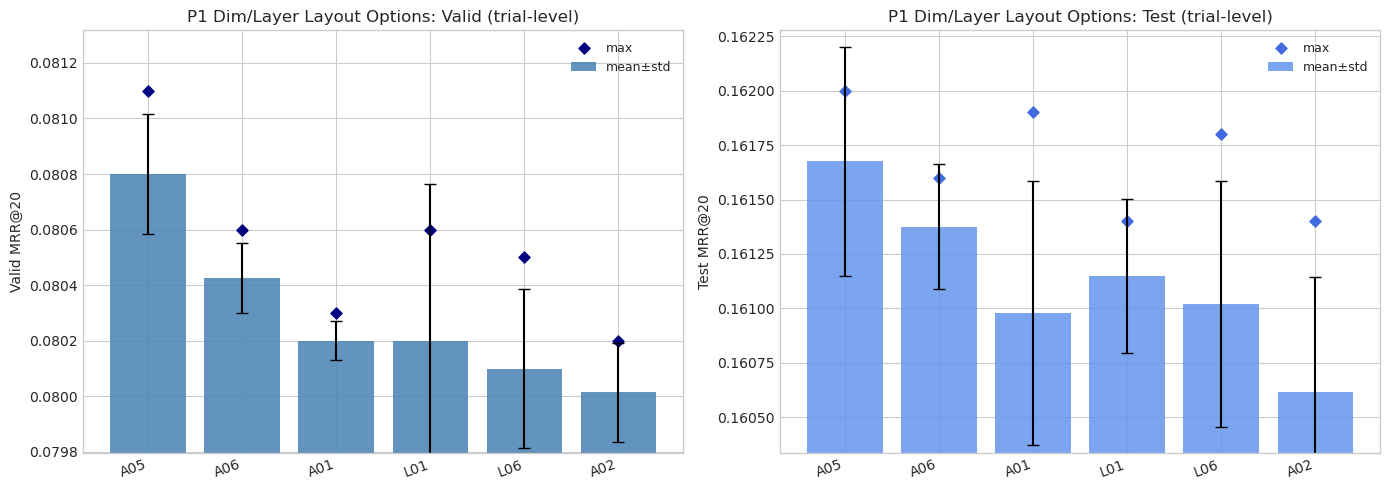


[해석] P1 dim/layer layout 품질/유망성
- 옵션별 Top6(평균 기준)과 family(A/L) 수준 통계를 함께 본다.
run_phase  n  valid_mean  valid_std  valid_max  test_mean  test_std  test_max
      A05  4    0.080800   0.000216     0.0811   0.161675  0.000525    0.1620
      A06  4    0.080425   0.000126     0.0806   0.161375  0.000287    0.1616
      A01  5    0.080200   0.000071     0.0803   0.160980  0.000606    0.1619
      L01  2    0.080200   0.000566     0.0806   0.161150  0.000354    0.1614
      L06 10    0.080100   0.000287     0.0805   0.161020  0.000565    0.1618
      A02  7    0.080014   0.000177     0.0802   0.160614  0.000530    0.1614

[family-level]
              family  n  valid_mean  valid_std  valid_max  test_mean  test_std  test_max
A-anchor(dim/layout) 35    0.078889   0.004251     0.0811   0.159331  0.006103    0.1622
      L-layer-layout 44    0.078436   0.005345     0.0807   0.157382  0.013084    0.1621


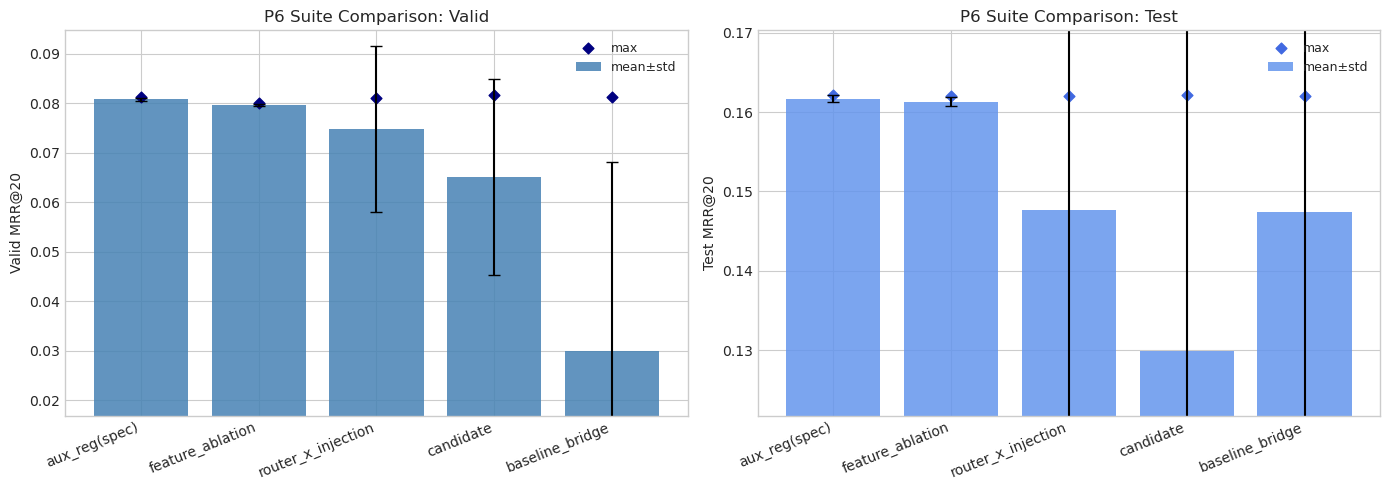


[해석] P6 suite 비교 (candidate/base/router×inj/aux-reg/feature)
             suite  n  valid_mean  valid_std  valid_max  test_mean  test_std  test_max
     aux_reg(spec) 10    0.080800   0.000371     0.0813   0.161690  0.000491    0.1622
  feature_ablation 33    0.079667   0.000286     0.0801   0.161309  0.000520    0.1620
router_x_injection  9    0.074811   0.016810     0.0812   0.147611  0.037135    0.1620
         candidate 53    0.065126   0.019895     0.0818   0.129857  0.044301    0.1621
   baseline_bridge 27    0.029885   0.038304     0.0813   0.147427  0.039546    0.1620


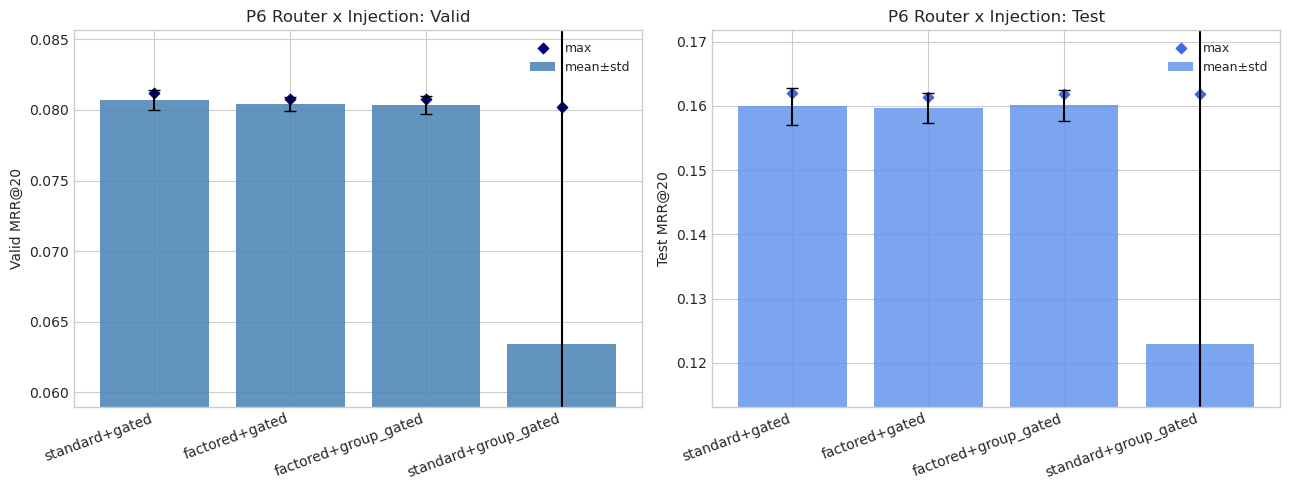


[해석] P6 router x injection (context 통합)
               combo  n  valid_mean  valid_std  valid_max  test_mean  test_std  test_max
      standard+gated  2    0.080700   0.000707     0.0812   0.159950  0.002899    0.1620
      factored+gated  2    0.080450   0.000495     0.0808   0.159750  0.002333    0.1614
factored+group_gated  2    0.080350   0.000636     0.0808   0.160100  0.002404    0.1618
standard+group_gated  3    0.063433   0.028954     0.0802   0.122967  0.064339    0.1618

[해석] P6 aux-reg(spec_ablation) method 비교
method  n  valid_mean  valid_std  valid_max  test_mean  test_std  test_max
    M0  2     0.08095   0.000354     0.0812    0.16210  0.000141    0.1622
    M1  2     0.08085   0.000354     0.0811    0.16185  0.000071    0.1619
    M2  2     0.08080   0.000424     0.0811    0.16190  0.000141    0.1620
    M3  2     0.08080   0.000707     0.0813    0.16180  0.000141    0.1619
    M4  2     0.08060   0.000424     0.0809    0.16080  0.000141    0.1609

[해석] P6 feature ablat

In [9]:
# Figure 7-9: Dim/Layer layout quality + Phase6 suite/theme analysis

# -----------------------------
# A) Dim/Layer layout quality & prospect (P1 trial-level)
# -----------------------------
phase1_trial = pd.read_csv(LOG_DIR / "phase1_upgrade_v1/phase1_upgrade_v1_summary.csv")
phase1_trial = phase1_trial[
    phase1_trial["log_rel_path"].astype(str).str.contains("KuaiRecLargeStrictPosV2_0.2", na=False)
].copy()

phase1_trial["run_phase"] = phase1_trial["run_phase"].astype(str)
dl = phase1_trial[phase1_trial["run_phase"].str.match(r"^(A\d+|L\d+)$", na=False)].copy()

def dl_family(rp: str) -> str:
    return "A-anchor(dim/layout)" if str(rp).startswith("A") else "L-layer-layout"

dl["family"] = dl["run_phase"].map(dl_family)

dl_stats = dl.groupby("run_phase", as_index=False).agg(
    n=("best_mrr20_trial", "count"),
    valid_mean=("best_mrr20_trial", "mean"),
    valid_std=("best_mrr20_trial", "std"),
    valid_max=("best_mrr20_trial", "max"),
    test_mean=("test_mrr20_trial", "mean"),
    test_std=("test_mrr20_trial", "std"),
    test_max=("test_mrr20_trial", "max"),
).sort_values("valid_mean", ascending=False)
dl_stats[["valid_std", "test_std"]] = dl_stats[["valid_std", "test_std"]].fillna(0.0)

# keep chart compact (<=6 categories)
dl_top = dl_stats.head(6).copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(dl_top))

ax1.bar(x, dl_top["valid_mean"], yerr=dl_top["valid_std"], capsize=4, color="steelblue", alpha=0.85, label="mean±std")
ax1.scatter(x, dl_top["valid_max"], color="navy", marker="D", s=32, label="max")
ax1.set_title("P1 Dim/Layer Layout Options: Valid (trial-level)")
ax1.set_xticks(x)
ax1.set_xticklabels(dl_top["run_phase"], rotation=20, ha="right")
ax1.set_ylabel("Valid MRR@20")
ax1.set_ylim(*zoom_ylim(np.r_[dl_top["valid_mean"], dl_top["valid_max"]], pad_ratio=0.2))
ax1.legend(fontsize=9)

ax2.bar(x, dl_top["test_mean"], yerr=dl_top["test_std"], capsize=4, color="cornflowerblue", alpha=0.85, label="mean±std")
ax2.scatter(x, dl_top["test_max"], color="royalblue", marker="D", s=32, label="max")
ax2.set_title("P1 Dim/Layer Layout Options: Test (trial-level)")
ax2.set_xticks(x)
ax2.set_xticklabels(dl_top["run_phase"], rotation=20, ha="right")
ax2.set_ylabel("Test MRR@20")
ax2.set_ylim(*zoom_ylim(np.r_[dl_top["test_mean"], dl_top["test_max"]], pad_ratio=0.2))
ax2.legend(fontsize=9)

plt.tight_layout()
maybe_savefig(FIG_DIR / "260319_clean_p1_dim_layer_top6.png", dpi=220, bbox_inches="tight")
plt.show()

family_stats = dl.groupby("family", as_index=False).agg(
    n=("best_mrr20_trial", "count"),
    valid_mean=("best_mrr20_trial", "mean"),
    valid_std=("best_mrr20_trial", "std"),
    valid_max=("best_mrr20_trial", "max"),
    test_mean=("test_mrr20_trial", "mean"),
    test_std=("test_mrr20_trial", "std"),
    test_max=("test_mrr20_trial", "max"),
).sort_values("valid_mean", ascending=False)
family_stats[["valid_std", "test_std"]] = family_stats[["valid_std", "test_std"]].fillna(0.0)

print("\n[해석] P1 dim/layer layout 품질/유망성")
print("- 옵션별 Top6(평균 기준)과 family(A/L) 수준 통계를 함께 본다.")
print(dl_top[["run_phase", "n", "valid_mean", "valid_std", "valid_max", "test_mean", "test_std", "test_max"]].to_string(index=False))
print("\n[family-level]")
print(family_stats.to_string(index=False))

# -----------------------------
# B) Phase6 suite-level comparison (run-level)
# -----------------------------
p6 = fmoe_unique[fmoe_unique["phase"].astype(str).eq("P6")].copy()

def p6_suite(run_id: str) -> str:
    rid = str(run_id).lower()
    if rid.startswith("p6_cand_"):
        return "candidate"
    if rid.startswith("p6_base_"):
        return "baseline_bridge"
    if rid.startswith("p6_rxi_"):
        return "router_x_injection"
    if rid.startswith("p6_spec_"):
        return "aux_reg(spec)"
    if rid.startswith("p6_feat_"):
        return "feature_ablation"
    return "other"

p6["suite"] = p6["run_id"].map(p6_suite)
p6 = p6[p6["suite"] != "other"].copy()

p6_suite_stats = p6.groupby("suite", as_index=False).agg(
    n=("run_id", "count"),
    valid_mean=("best_valid_mrr20", "mean"),
    valid_std=("best_valid_mrr20", "std"),
    valid_max=("best_valid_mrr20", "max"),
    test_mean=("best_valid_test_mrr20", "mean"),
    test_std=("best_valid_test_mrr20", "std"),
    test_max=("best_valid_test_mrr20", "max"),
).sort_values("valid_mean", ascending=False)
p6_suite_stats[["valid_std", "test_std"]] = p6_suite_stats[["valid_std", "test_std"]].fillna(0.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(p6_suite_stats))

ax1.bar(x, p6_suite_stats["valid_mean"], yerr=p6_suite_stats["valid_std"], capsize=4, color="steelblue", alpha=0.85, label="mean±std")
ax1.scatter(x, p6_suite_stats["valid_max"], color="navy", marker="D", s=30, label="max")
ax1.set_title("P6 Suite Comparison: Valid")
ax1.set_xticks(x)
ax1.set_xticklabels(p6_suite_stats["suite"], rotation=22, ha="right")
ax1.set_ylabel("Valid MRR@20")
ax1.set_ylim(*zoom_ylim(np.r_[p6_suite_stats["valid_mean"], p6_suite_stats["valid_max"]], pad_ratio=0.25))
ax1.legend(fontsize=9)

ax2.bar(x, p6_suite_stats["test_mean"], yerr=p6_suite_stats["test_std"], capsize=4, color="cornflowerblue", alpha=0.85, label="mean±std")
ax2.scatter(x, p6_suite_stats["test_max"], color="royalblue", marker="D", s=30, label="max")
ax2.set_title("P6 Suite Comparison: Test")
ax2.set_xticks(x)
ax2.set_xticklabels(p6_suite_stats["suite"], rotation=22, ha="right")
ax2.set_ylabel("Test MRR@20")
ax2.set_ylim(*zoom_ylim(np.r_[p6_suite_stats["test_mean"], p6_suite_stats["test_max"]], pad_ratio=0.25))
ax2.legend(fontsize=9)

plt.tight_layout()
maybe_savefig(FIG_DIR / "260319_clean_p6_suite_stats.png", dpi=220, bbox_inches="tight")
plt.show()

print("\n[해석] P6 suite 비교 (candidate/base/router×inj/aux-reg/feature)")
print(p6_suite_stats.to_string(index=False))

# -----------------------------
# C) P6 theme deep-dive: router×injection / aux-reg(spec) / feature ablation
# -----------------------------

# C1) router x injection
rxi = p6[p6["run_id"].str.startswith("p6_rxi_", na=False)].copy()
pat_rxi = re.compile(r"p6_rxi_x(?P<context>[12])_(?P<router>sta|fac)_(?P<inj>gat|gro)")

def parse_rxi(rid: str):
    m = pat_rxi.search(str(rid))
    if not m:
        return pd.Series([None, None, None, None])
    context = f"X{m.group('context')}"
    router = "standard" if m.group("router") == "sta" else "factored"
    inj = "gated" if m.group("inj") == "gat" else "group_gated"
    combo = f"{router}+{inj}"
    return pd.Series([context, router, inj, combo])

if len(rxi) > 0:
    rxi[["context", "router", "inj", "combo"]] = rxi["run_id"].apply(parse_rxi)
    rxi_stats = rxi.groupby("combo", as_index=False).agg(
        n=("run_id", "count"),
        valid_mean=("best_valid_mrr20", "mean"),
        valid_std=("best_valid_mrr20", "std"),
        valid_max=("best_valid_mrr20", "max"),
        test_mean=("best_valid_test_mrr20", "mean"),
        test_std=("best_valid_test_mrr20", "std"),
        test_max=("best_valid_test_mrr20", "max"),
    ).sort_values("valid_mean", ascending=False)
    rxi_stats[["valid_std", "test_std"]] = rxi_stats[["valid_std", "test_std"]].fillna(0.0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    x = np.arange(len(rxi_stats))

    ax1.bar(x, rxi_stats["valid_mean"], yerr=rxi_stats["valid_std"], capsize=4, color="steelblue", alpha=0.85, label="mean±std")
    ax1.scatter(x, rxi_stats["valid_max"], color="navy", marker="D", s=28, label="max")
    ax1.set_title("P6 Router x Injection: Valid")
    ax1.set_xticks(x)
    ax1.set_xticklabels(rxi_stats["combo"], rotation=20, ha="right")
    ax1.set_ylabel("Valid MRR@20")
    ax1.set_ylim(*zoom_ylim(np.r_[rxi_stats["valid_mean"], rxi_stats["valid_max"]], pad_ratio=0.25))
    ax1.legend(fontsize=9)

    ax2.bar(x, rxi_stats["test_mean"], yerr=rxi_stats["test_std"], capsize=4, color="cornflowerblue", alpha=0.85, label="mean±std")
    ax2.scatter(x, rxi_stats["test_max"], color="royalblue", marker="D", s=28, label="max")
    ax2.set_title("P6 Router x Injection: Test")
    ax2.set_xticks(x)
    ax2.set_xticklabels(rxi_stats["combo"], rotation=20, ha="right")
    ax2.set_ylabel("Test MRR@20")
    ax2.set_ylim(*zoom_ylim(np.r_[rxi_stats["test_mean"], rxi_stats["test_max"]], pad_ratio=0.25))
    ax2.legend(fontsize=9)

    plt.tight_layout()
    maybe_savefig(FIG_DIR / "260319_clean_p6_rxi_stats.png", dpi=220, bbox_inches="tight")
    plt.show()

    print("\n[해석] P6 router x injection (context 통합)")
    print(rxi_stats.to_string(index=False))
else:
    print("\n[해석] P6 router x injection: 데이터 없음")

# C2) aux-reg(spec)
spec = p6[p6["run_id"].str.startswith("p6_spec_", na=False)].copy()
pat_spec = re.compile(r"p6_spec_(?P<anchor>[ab])_m(?P<m>[0-4])")
if len(spec) > 0:
    spec[["anchor", "method"]] = spec["run_id"].apply(
        lambda rid: pd.Series([
            (pat_spec.search(str(rid)).group("anchor").upper() if pat_spec.search(str(rid)) else None),
            (f"M{pat_spec.search(str(rid)).group('m')}" if pat_spec.search(str(rid)) else None),
        ])
    )
    spec_stats = spec.groupby("method", as_index=False).agg(
        n=("run_id", "count"),
        valid_mean=("best_valid_mrr20", "mean"),
        valid_std=("best_valid_mrr20", "std"),
        valid_max=("best_valid_mrr20", "max"),
        test_mean=("best_valid_test_mrr20", "mean"),
        test_std=("best_valid_test_mrr20", "std"),
        test_max=("best_valid_test_mrr20", "max"),
    ).sort_values("method")
    spec_stats[["valid_std", "test_std"]] = spec_stats[["valid_std", "test_std"]].fillna(0.0)

    print("\n[해석] P6 aux-reg(spec_ablation) method 비교")
    print(spec_stats.to_string(index=False))
else:
    print("\n[해석] P6 aux-reg(spec): 데이터 없음")

# C3) feature ablation
feat = p6[p6["run_id"].str.startswith("p6_feat_", na=False)].copy()
pat_feat = re.compile(r"p6_feat_w(?P<w>5|10)_(?P<mask>[a-z_]+)")
if len(feat) > 0:
    feat[["window", "mask"]] = feat["run_id"].apply(
        lambda rid: pd.Series([
            (f"W{pat_feat.search(str(rid)).group('w')}" if pat_feat.search(str(rid)) else None),
            (pat_feat.search(str(rid)).group("mask") if pat_feat.search(str(rid)) else None),
        ])
    )

    feat_w_stats = feat.groupby("window", as_index=False).agg(
        n=("run_id", "count"),
        valid_mean=("best_valid_mrr20", "mean"),
        valid_std=("best_valid_mrr20", "std"),
        valid_max=("best_valid_mrr20", "max"),
        test_mean=("best_valid_test_mrr20", "mean"),
        test_std=("best_valid_test_mrr20", "std"),
        test_max=("best_valid_test_mrr20", "max"),
    ).sort_values("window")
    feat_w_stats[["valid_std", "test_std"]] = feat_w_stats[["valid_std", "test_std"]].fillna(0.0)

    feat_mask_stats = feat.groupby("mask", as_index=False).agg(
        n=("run_id", "count"),
        valid_mean=("best_valid_mrr20", "mean"),
        test_mean=("best_valid_test_mrr20", "mean"),
    ).sort_values("valid_mean", ascending=False).head(6)

    print("\n[해석] P6 feature ablation window 비교")
    print(feat_w_stats.to_string(index=False))
    print("\n[해석] P6 feature mask Top6 (평균 valid 기준)")
    print(feat_mask_stats.to_string(index=False))
else:
    print("\n[해석] P6 feature ablation: 데이터 없음")

print("\n[요약 메모]")
print("- P1 dim/layer는 trial-level 분산까지 반영해 '안정적 상위 옵션'과 '단발 피크 옵션'을 분리해 해석 가능")
print("- P6는 suite-level로 전체 방향성을 보고, rxi/spec/feature 블록으로 인과 축을 세분화")

In [10]:
# Layout + Feature-injection consolidated tables (best valid MRR@20 중심)
from pathlib import Path
import re
import pandas as pd

cwd = Path.cwd().resolve()
ROOT = None
for p in [cwd] + list(cwd.parents):
    if (p / "experiments").exists() and (p / "Makefile").exists():
        ROOT = p
        break
if ROOT is None:
    raise RuntimeError("Could not locate repository root containing experiments/ and Makefile")

DATA_DIR = ROOT / "experiments/run/fmoe_n3/docs/data"
LOG_DIR = ROOT / "experiments/run/artifacts/logs/fmoe_n3"
OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

fmoe = pd.read_csv(DATA_DIR / "260319_fmoe_n3_kuairec_all.csv")
fmoe_unique = (
    fmoe.sort_values(["best_valid_mrr20", "best_valid_test_mrr20"], ascending=False)
    .drop_duplicates(subset=["run_id"], keep="first")
    .copy()
)

base = pd.read_csv(DATA_DIR / "260319_baseline_kuairec_model_best.csv")
sas_row = base[base["model"].astype(str).str.upper().eq("SASREC")].head(1)
if len(sas_row) == 0:
    raise RuntimeError("SASRec baseline row not found in baseline model-best CSV")
sas_valid = float(sas_row["best_valid_mrr20"].iloc[0])

# ---------- layout: P3 ----------
def p3_option(run_id: str) -> str:
    rid = str(run_id).lower()
    if "p3s1_" in rid:
        return "S1_flat_standard"
    if "p3s2_" in rid:
        return "S2_factored_group"
    if "p3s3_" in rid:
        return "S3_feature_source"
    if "p3s4_" in rid:
        return "S4_deep_prefix"
    return "other"

p3 = fmoe_unique[fmoe_unique["run_id"].astype(str).str.contains(r"^p3s[1-4]_", regex=True, na=False)].copy()
p3["layout_option"] = p3["run_id"].map(p3_option)

p3_stats = p3.groupby("layout_option", as_index=False).agg(
    n_runs=("run_id", "count"),
    valid_mean=("best_valid_mrr20", "mean"),
    valid_max=("best_valid_mrr20", "max"),
    test_mean=("best_valid_test_mrr20", "mean"),
    test_max=("best_valid_test_mrr20", "max"),
)
p3_stats = p3_stats[p3_stats["layout_option"] != "other"].sort_values("valid_mean", ascending=False)
p3_best = p3.loc[p3.groupby("layout_option")["best_valid_mrr20"].idxmax(), ["layout_option", "run_id", "best_valid_mrr20", "best_valid_test_mrr20"]]
p3_table = p3_stats.merge(p3_best, on="layout_option", how="left", suffixes=("", "_best_run"))
p3_table["delta_vs_sasrec_valid"] = p3_table["valid_max"] - sas_valid

# ---------- layout: P1 (trial-level A/L) ----------
phase1 = pd.read_csv(LOG_DIR / "phase1_upgrade_v1/phase1_upgrade_v1_summary.csv")
phase1 = phase1[phase1["log_rel_path"].astype(str).str.contains("KuaiRecLargeStrictPosV2_0.2", na=False)].copy()
phase1 = phase1[phase1["run_phase"].astype(str).str.match(r"^(A\d+|L\d+)$", na=False)].copy()
phase1["family"] = phase1["run_phase"].astype(str).str[0].map({"A": "A_anchor_dim_layout", "L": "L_layer_layout"})

p1_phase_table = phase1.groupby(["run_phase", "family"], as_index=False).agg(
    n_trials=("best_mrr20_trial", "count"),
    valid_mean=("best_mrr20_trial", "mean"),
    valid_max=("best_mrr20_trial", "max"),
    test_mean=("test_mrr20_trial", "mean"),
    test_max=("test_mrr20_trial", "max"),
).sort_values("valid_mean", ascending=False)
p1_phase_table["delta_vs_sasrec_valid"] = p1_phase_table["valid_max"] - sas_valid

p1_family_table = phase1.groupby("family", as_index=False).agg(
    n_trials=("best_mrr20_trial", "count"),
    valid_mean=("best_mrr20_trial", "mean"),
    valid_max=("best_mrr20_trial", "max"),
    test_mean=("test_mrr20_trial", "mean"),
    test_max=("test_mrr20_trial", "max"),
).sort_values("valid_mean", ascending=False)
p1_family_table["delta_vs_sasrec_valid"] = p1_family_table["valid_max"] - sas_valid

# ---------- feature path: hidden / feature / both / injection ----------
f_path = fmoe_unique[fmoe_unique["run_id"].astype(str).str.startswith("f_feat_", na=False)].copy()

def feat_path_label(run_id: str) -> str:
    rid = str(run_id)
    if "f_feat_hidden_only_" in rid:
        return "hidden_only_router"
    if "f_feat_feature_only_" in rid:
        return "feature_only_router"
    if "f_feat_full_" in rid:
        return "hidden_plus_feature_router"
    if "f_feat_injection_only_" in rid:
        return "injection_only"
    return "other"

f_path["path_type"] = f_path["run_id"].map(feat_path_label)
f_path_table = f_path.groupby("path_type", as_index=False).agg(
    n_runs=("run_id", "count"),
    valid_mean=("best_valid_mrr20", "mean"),
    valid_max=("best_valid_mrr20", "max"),
    test_mean=("best_valid_test_mrr20", "mean"),
    test_max=("best_valid_test_mrr20", "max"),
)
f_path_table = f_path_table[f_path_table["path_type"] != "other"].sort_values("valid_mean", ascending=False)
f_best = f_path.loc[f_path.groupby("path_type")["best_valid_mrr20"].idxmax(), ["path_type", "run_id", "best_valid_mrr20", "best_valid_test_mrr20"]]
f_path_table = f_path_table.merge(f_best, on="path_type", how="left", suffixes=("", "_best_run"))
f_path_table["delta_vs_sasrec_valid"] = f_path_table["valid_max"] - sas_valid

# ---------- feature route x injection (P6 rxi) ----------
rxi = fmoe_unique[fmoe_unique["run_id"].astype(str).str.startswith("p6_rxi_", na=False)].copy()
pat_rxi = re.compile(r"p6_rxi_x(?P<context>[12])_(?P<router>sta|fac)_(?P<inj>gat|gro)")

def parse_rxi(rid: str):
    m = pat_rxi.search(str(rid))
    if not m:
        return pd.Series([None, None, None, None])
    context = f"X{m.group('context')}"
    router = "standard" if m.group("router") == "sta" else "factored"
    inj = "gated" if m.group("inj") == "gat" else "group_gated"
    combo = f"{router}+{inj}"
    return pd.Series([context, router, inj, combo])

if len(rxi) > 0:
    rxi[["context", "router_type", "inj_type", "combo"]] = rxi["run_id"].apply(parse_rxi)
    rxi_combo_table = rxi.groupby("combo", as_index=False).agg(
        n_runs=("run_id", "count"),
        valid_mean=("best_valid_mrr20", "mean"),
        valid_max=("best_valid_mrr20", "max"),
        test_mean=("best_valid_test_mrr20", "mean"),
        test_max=("best_valid_test_mrr20", "max"),
    ).sort_values("valid_mean", ascending=False)
    rxi_context_table = rxi.groupby("context", as_index=False).agg(
        n_runs=("run_id", "count"),
        valid_mean=("best_valid_mrr20", "mean"),
        valid_max=("best_valid_mrr20", "max"),
        test_mean=("best_valid_test_mrr20", "mean"),
        test_max=("best_valid_test_mrr20", "max"),
    ).sort_values("valid_mean", ascending=False)
    rxi_combo_table["delta_vs_sasrec_valid"] = rxi_combo_table["valid_max"] - sas_valid
    rxi_context_table["delta_vs_sasrec_valid"] = rxi_context_table["valid_max"] - sas_valid
else:
    rxi_combo_table = pd.DataFrame(columns=["combo", "n_runs", "valid_mean", "valid_max", "test_mean", "test_max", "delta_vs_sasrec_valid"])
    rxi_context_table = pd.DataFrame(columns=["context", "n_runs", "valid_mean", "valid_max", "test_mean", "test_max", "delta_vs_sasrec_valid"])

# ---------- rule-based keyword evidence ----------
rule_hits = fmoe_unique[fmoe_unique["run_id"].astype(str).str.contains(r"rule|teacher|gls", regex=True, case=False, na=False)].copy()

# ---------- save tables ----------
p3_table.to_csv(OUT_DIR / "260318_layout_p3_summary.csv", index=False)
p1_phase_table.to_csv(OUT_DIR / "260318_layout_p1_phase_summary.csv", index=False)
p1_family_table.to_csv(OUT_DIR / "260318_layout_p1_family_summary.csv", index=False)
f_path_table.to_csv(OUT_DIR / "260318_feature_path_summary.csv", index=False)
rxi_combo_table.to_csv(OUT_DIR / "260318_feature_rxi_combo_summary.csv", index=False)
rxi_context_table.to_csv(OUT_DIR / "260318_feature_rxi_context_summary.csv", index=False)
rule_hits.to_csv(OUT_DIR / "260318_feature_rule_keyword_hits.csv", index=False)

report_lines = []
report_lines.append("# 260318 layout + feature summary (best valid MRR@20)")
report_lines.append("")
report_lines.append(f"- deduped run rows: {len(fmoe_unique)}")
report_lines.append(f"- SASRec best valid MRR@20: {sas_valid:.4f}")
report_lines.append(f"- rule keyword hits in run_id (rule/teacher/gls): {len(rule_hits)}")
report_lines.append("")
report_lines.append("## P3 layout options")
report_lines.append(p3_table[["layout_option", "n_runs", "valid_mean", "valid_max", "delta_vs_sasrec_valid", "run_id"]].to_markdown(index=False))
report_lines.append("")
report_lines.append("## P1 family summary")
report_lines.append(p1_family_table[["family", "n_trials", "valid_mean", "valid_max", "delta_vs_sasrec_valid"]].to_markdown(index=False))
report_lines.append("")
report_lines.append("## P1 top-10 run_phase")
report_lines.append(p1_phase_table.head(10)[["run_phase", "family", "n_trials", "valid_mean", "valid_max", "delta_vs_sasrec_valid"]].to_markdown(index=False))
report_lines.append("")
report_lines.append("## feature path (hidden/feature/both/injection)")
report_lines.append(f_path_table[["path_type", "n_runs", "valid_mean", "valid_max", "delta_vs_sasrec_valid", "run_id"]].to_markdown(index=False))
report_lines.append("")
report_lines.append("## P6 router x injection combo")
report_lines.append(rxi_combo_table[["combo", "n_runs", "valid_mean", "valid_max", "delta_vs_sasrec_valid"]].to_markdown(index=False))
report_lines.append("")
report_lines.append("## P6 context (X1/X2)")
report_lines.append(rxi_context_table[["context", "n_runs", "valid_mean", "valid_max", "delta_vs_sasrec_valid"]].to_markdown(index=False))

(OUT_DIR / "260318_layout_feature_mrr20_summary.md").write_text("\n".join(report_lines), encoding="utf-8")

print(f"SASRec best valid MRR@20 = {sas_valid:.4f}")
print(f"deduped FMoE runs = {len(fmoe_unique)}")
print(f"rule keyword hits = {len(rule_hits)}")
print("\n[P3 layout option summary]")
print(p3_table[["layout_option", "n_runs", "valid_mean", "valid_max", "delta_vs_sasrec_valid"]].to_string(index=False))
print("\n[P1 family summary]")
print(p1_family_table[["family", "n_trials", "valid_mean", "valid_max", "delta_vs_sasrec_valid"]].to_string(index=False))
print("\n[feature path summary]")
print(f_path_table[["path_type", "n_runs", "valid_mean", "valid_max", "delta_vs_sasrec_valid"]].to_string(index=False))
print("\n[P6 router x injection combo summary]")
print(rxi_combo_table[["combo", "n_runs", "valid_mean", "valid_max", "delta_vs_sasrec_valid"]].to_string(index=False))

SASRec best valid MRR@20 = 0.0785
deduped FMoE runs = 371
rule keyword hits = 0

[P3 layout option summary]
    layout_option  n_runs  valid_mean  valid_max  delta_vs_sasrec_valid
 S1_flat_standard       6     0.08105     0.0813                 0.0028
S2_factored_group       5     0.08102     0.0811                 0.0026
S3_feature_source       1     0.08090     0.0809                 0.0024
   S4_deep_prefix       1     0.08040     0.0804                 0.0019

[P1 family summary]
             family  n_trials  valid_mean  valid_max  delta_vs_sasrec_valid
A_anchor_dim_layout        35    0.078889     0.0811                 0.0026
     L_layer_layout        44    0.078436     0.0807                 0.0022

[feature path summary]
                 path_type  n_runs  valid_mean  valid_max  delta_vs_sasrec_valid
hidden_plus_feature_router       1      0.0813     0.0813                 0.0028
       feature_only_router       1      0.0807     0.0807                 0.0022
            inje

## Figure 10: Standard vs Group-wise(Factored) Integrated Comparison

This section compares `standard` and `group-wise(factored)` routing families across multiple experiment sets.

Coverage:
- General performance: `best_valid_mrr20`, `test_mrr20` from run summaries
- Routing behavior (diag): `macro_n_eff_scope_norm`, `macro_cv_usage`, `macro_top1_over_scope_uniform`, `macro_knn_js`
- Special slices: cold item (`target_popularity_abs <=5`) and cold session (`session_len 1-2`, `3-5`)

Data sources are aggregated from phase-level logs/artifacts, then normalized into two router families for side-by-side comparison.


[General performance] standard vs factored
  family  n_runs  valid_mean  valid_std  valid_max  test_mean  test_std  test_max
factored       9    0.080444   0.000317     0.0808   0.160867  0.001535    0.1620
standard       9    0.080811   0.000496     0.0813   0.160989  0.001655    0.1622

[Routing diag mean] standard vs factored
  family  macro_n_eff_scope_norm  macro_cv_usage  macro_top1_over_scope_uniform  macro_knn_js
factored                4.757290        0.470270                       0.816550      0.051967
standard                3.336067        0.519628                       2.288429      0.061826

[Special slices mean(test split)] standard vs factored
  family  n_runs  overall_test_mrr20  cold_item_le5_mrr20  cold_sess_1_2_mrr20  cold_sess_3_5_mrr20
factored      14            0.161051             0.118303             0.000579             0.149785
standard      16            0.161302             0.119508             0.000468             0.150414


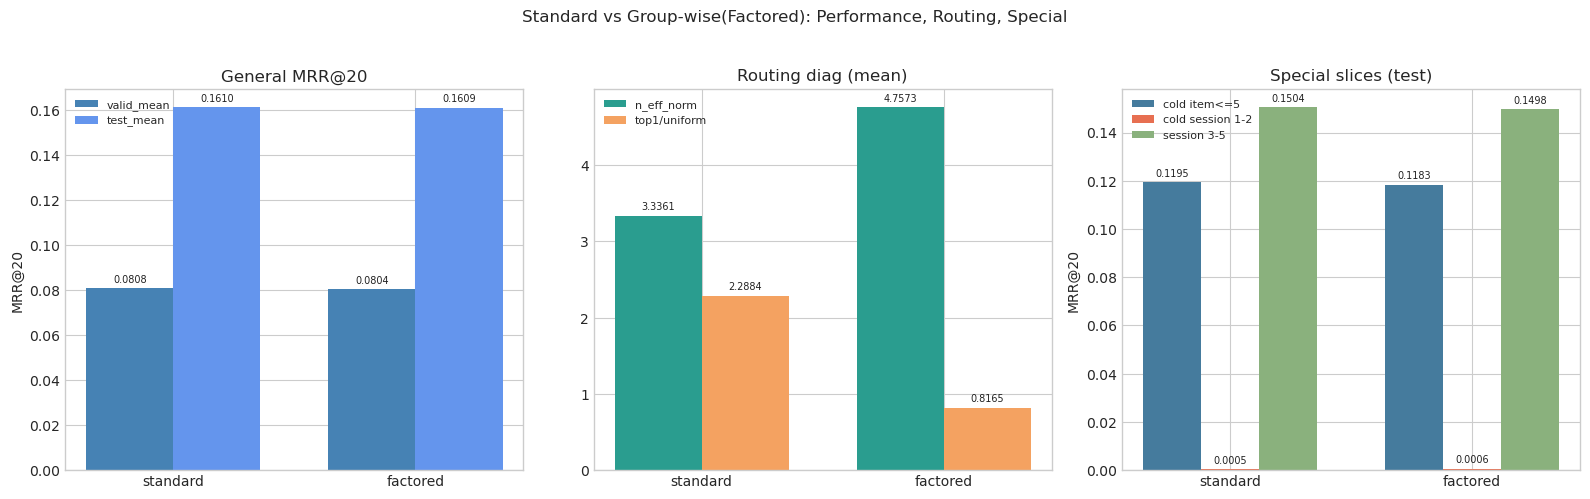


[요약 해석]
- 일반 성능 차이 (factored-standard): valid_mean=-0.0004, test_mean=-0.0001
- cold item<=5 차이 (factored-standard): -0.0012
- cold session 1-2 차이 (factored-standard): +0.0001


In [12]:
# Figure 10 code: standard vs group-wise(factored) across performance/diag/special
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve ROOT safely (reuse existing ROOT if available)
if "ROOT" not in globals() or ROOT is None:
    cwd = Path.cwd().resolve()
    ROOT = None
    for p in [cwd] + list(cwd.parents):
        if (p / "experiments").exists() and (p / "Makefile").exists():
            ROOT = p
            break
    if ROOT is None:
        raise RuntimeError("Could not locate repository root")

DIAG_CSV = ROOT / "outputs/phase56_corr/phase56_diag_join_enriched_v3_scopeaware.csv"
LOGGING_ROOT = ROOT / "experiments/run/artifacts/logging/fmoe_n3/KuaiRecLargeStrictPosV2_0.2"
SPECIAL_ROOT = ROOT / "experiments/run/artifacts/results/fmoe_n3/special"

def classify_router_family(run_phase: str, run_name: str = "") -> str:
    rp = str(run_phase).upper()
    rn = str(run_name).lower()

    # Explicit phase patterns first
    if "SPEC_A" in rp:
        return "standard"
    if "SPEC_B" in rp:
        return "factored"
    if "RXI" in rp and "_STA_" in rp:
        return "standard"
    if "RXI" in rp and "_FAC_" in rp:
        return "factored"
    if rp.startswith("P3S1"):
        return "standard"
    if rp.startswith("P3S2"):
        return "factored"

    # Name fallback
    if "_sta_" in rn or "standard" in rn:
        return "standard"
    if "_fac_" in rn or "factored" in rn:
        return "factored"

    return "other"

def safe_nested(d, keys, default=np.nan):
    cur = d
    for k in keys:
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur

def annotate_bars(ax, bar_container, fmt="{:.4f}", fontsize=7, y_offset_ratio=0.01):
    vals = [b.get_height() for b in bar_container]
    finite_vals = [v for v in vals if np.isfinite(v)]
    if not finite_vals:
        return
    ymin, ymax = ax.get_ylim()
    yspan = ymax - ymin if ymax > ymin else 1.0
    dy = yspan * y_offset_ratio
    for b in bar_container:
        h = b.get_height()
        if not np.isfinite(h):
            continue
        ax.text(
            b.get_x() + b.get_width() / 2,
            h + dy,
            fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=fontsize,
            color="#222222",
            rotation=0,
        )

# ---------------------------------------------------------------------
# 1) General performance from run_summary.json (multi-phase coverage)
# ---------------------------------------------------------------------
perf_rows = []
for p in sorted(LOGGING_ROOT.glob("**/run_summary.json")):
    try:
        obj = json.loads(p.read_text(encoding="utf-8"))
    except Exception:
        continue

    run_phase = obj.get("run_phase", "")
    run_name = obj.get("run_name", "")
    fam = classify_router_family(run_phase, run_name)
    if fam not in ("standard", "factored"):
        continue

    perf_rows.append(
        {
            "run_phase": run_phase,
            "run_name": run_name,
            "family": fam,
            "best_valid_mrr20": obj.get("best_mrr@20", np.nan),
            "test_mrr20": obj.get("test_mrr@20", np.nan),
            "bundle_dir": obj.get("bundle_dir", ""),
        }
    )

perf_df = pd.DataFrame(perf_rows)
if len(perf_df) == 0:
    raise RuntimeError("No standard/factored run_summary rows found for KuaiRecLargeStrictPosV2_0.2")

perf_summary = (
    perf_df.groupby("family", as_index=False)
    .agg(
        n_runs=("run_phase", "count"),
        valid_mean=("best_valid_mrr20", "mean"),
        valid_std=("best_valid_mrr20", "std"),
        valid_max=("best_valid_mrr20", "max"),
        test_mean=("test_mrr20", "mean"),
        test_std=("test_mrr20", "std"),
        test_max=("test_mrr20", "max"),
    )
)
perf_summary[["valid_std", "test_std"]] = perf_summary[["valid_std", "test_std"]].fillna(0.0)

# ---------------------------------------------------------------------
# 2) Routing diag comparison
# ---------------------------------------------------------------------
if not DIAG_CSV.exists():
    raise RuntimeError(f"Diag table not found: {DIAG_CSV}")

diag = pd.read_csv(DIAG_CSV)
diag = diag.copy()
diag["family"] = diag.apply(
    lambda r: classify_router_family(r.get("run_phase", ""), r.get("run_name", "")), axis=1
)
diag = diag[diag["family"].isin(["standard", "factored"])].copy()

diag_cols = [
    "macro_n_eff_scope_norm",
    "macro_cv_usage",
    "macro_top1_over_scope_uniform",
    "macro_knn_js",
]
for c in diag_cols:
    if c not in diag.columns:
        diag[c] = np.nan

diag_summary = (
    diag.groupby("family", as_index=False)[diag_cols]
    .mean(numeric_only=True)
    .sort_values("family")
)

# ---------------------------------------------------------------------
# 3) Special logging (cold slices)
# ---------------------------------------------------------------------
spec_rows = []
for p in sorted(SPECIAL_ROOT.glob("**/*_special_metrics.json")):
    try:
        obj = json.loads(p.read_text(encoding="utf-8"))
    except Exception:
        continue

    if str(obj.get("dataset", "")) != "KuaiRecLargeStrictPosV2_0.2":
        continue

    run_phase = obj.get("run_phase", "")
    fam = classify_router_family(run_phase, "")
    if fam not in ("standard", "factored"):
        continue

    # Prefer test split for production-like view
    test_block = obj.get("test_special_metrics", {})
    spec_rows.append(
        {
            "run_phase": run_phase,
            "family": fam,
            "overall_test_mrr20": safe_nested(test_block, ["overall", "mrr@20"]),
            "cold_item_le5_mrr20": safe_nested(test_block, ["slices", "target_popularity_abs", "<=5", "mrr@20"]),
            "cold_sess_1_2_mrr20": safe_nested(test_block, ["slices", "session_len", "1-2", "mrr@20"]),
            "cold_sess_3_5_mrr20": safe_nested(test_block, ["slices", "session_len", "3-5", "mrr@20"]),
        }
    )

spec_df = pd.DataFrame(spec_rows)
if len(spec_df) == 0:
    special_summary = pd.DataFrame(
        {
            "family": ["standard", "factored"],
            "n_runs": [0, 0],
            "overall_test_mrr20": [np.nan, np.nan],
            "cold_item_le5_mrr20": [np.nan, np.nan],
            "cold_sess_1_2_mrr20": [np.nan, np.nan],
            "cold_sess_3_5_mrr20": [np.nan, np.nan],
        }
    )
else:
    special_summary = (
        spec_df.groupby("family", as_index=False)
        .agg(
            n_runs=("run_phase", "count"),
            overall_test_mrr20=("overall_test_mrr20", "mean"),
            cold_item_le5_mrr20=("cold_item_le5_mrr20", "mean"),
            cold_sess_1_2_mrr20=("cold_sess_1_2_mrr20", "mean"),
            cold_sess_3_5_mrr20=("cold_sess_3_5_mrr20", "mean"),
        )
        .sort_values("family")
    )

# ---------------------------------------------------------------------
# 4) Print integrated tables
# ---------------------------------------------------------------------
print("\n[General performance] standard vs factored")
print(perf_summary.to_string(index=False))

print("\n[Routing diag mean] standard vs factored")
print(diag_summary.to_string(index=False))

print("\n[Special slices mean(test split)] standard vs factored")
print(special_summary.to_string(index=False))

# ---------------------------------------------------------------------
# 5) Visualization
# ---------------------------------------------------------------------
fam_order = [f for f in ["standard", "factored"] if f in set(perf_summary["family"])]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# (a) General performance
perf_plot = perf_summary.set_index("family").reindex(fam_order)
x = np.arange(len(perf_plot))
width = 0.36
bars_a1 = axes[0].bar(x - width/2, perf_plot["valid_mean"], width=width, label="valid_mean", color="steelblue")
bars_a2 = axes[0].bar(x + width/2, perf_plot["test_mean"], width=width, label="test_mean", color="cornflowerblue")
axes[0].set_xticks(x)
axes[0].set_xticklabels(perf_plot.index)
axes[0].set_title("General MRR@20")
axes[0].set_ylabel("MRR@20")
axes[0].legend(fontsize=8)
annotate_bars(axes[0], bars_a1, fontsize=7)
annotate_bars(axes[0], bars_a2, fontsize=7)

# (b) Routing diag
diag_plot = diag_summary.set_index("family").reindex(fam_order)
bars_b1 = axes[1].bar(x - width/2, diag_plot["macro_n_eff_scope_norm"], width=width, label="n_eff_norm", color="#2a9d8f")
bars_b2 = axes[1].bar(x + width/2, diag_plot["macro_top1_over_scope_uniform"], width=width, label="top1/uniform", color="#f4a261")
axes[1].set_xticks(x)
axes[1].set_xticklabels(fam_order)
axes[1].set_title("Routing diag (mean)")
axes[1].legend(fontsize=8)
annotate_bars(axes[1], bars_b1, fontsize=7)
annotate_bars(axes[1], bars_b2, fontsize=7)

# (c) Cold slices as grouped bars (not line)
sp = special_summary.set_index("family").reindex(fam_order)
w3 = 0.24
bars_c1 = axes[2].bar(x - w3, sp["cold_item_le5_mrr20"], width=w3, label="cold item<=5", color="#457b9d")
bars_c2 = axes[2].bar(x, sp["cold_sess_1_2_mrr20"], width=w3, label="cold session 1-2", color="#e76f51")
bars_c3 = axes[2].bar(x + w3, sp["cold_sess_3_5_mrr20"], width=w3, label="session 3-5", color="#8ab17d")
axes[2].set_xticks(x)
axes[2].set_xticklabels(fam_order)
axes[2].set_title("Special slices (test)")
axes[2].set_ylabel("MRR@20")
axes[2].legend(fontsize=8)
annotate_bars(axes[2], bars_c1, fontsize=7)
annotate_bars(axes[2], bars_c2, fontsize=7)
annotate_bars(axes[2], bars_c3, fontsize=7)

plt.suptitle("Standard vs Group-wise(Factored): Performance, Routing, Special", y=1.03)
plt.tight_layout()
plt.show()

# Brief interpretation helper
if set(["standard", "factored"]).issubset(set(perf_plot.index)):
    dv = perf_plot.loc["factored", "valid_mean"] - perf_plot.loc["standard", "valid_mean"]
    dt = perf_plot.loc["factored", "test_mean"] - perf_plot.loc["standard", "test_mean"]
    print("\n[요약 해석]")
    print(f"- 일반 성능 차이 (factored-standard): valid_mean={dv:+.4f}, test_mean={dt:+.4f}")
    if len(sp) > 0 and set(["standard", "factored"]).issubset(set(sp.index)):
        dc = sp.loc["factored", "cold_item_le5_mrr20"] - sp.loc["standard", "cold_item_le5_mrr20"]
        ds = sp.loc["factored", "cold_sess_1_2_mrr20"] - sp.loc["standard", "cold_sess_1_2_mrr20"]
        print(f"- cold item<=5 차이 (factored-standard): {dc:+.4f}")
        print(f"- cold session 1-2 차이 (factored-standard): {ds:+.4f}")